# Milestone 1: Data Exploration and Preprocessing
This notebook downloads a subset of the MIT-BIH dataset and visualizes the raw ECG signals and annotations.

In [1]:
# Install requirements (uncomment if running in Colab)
!pip install wfdb numpy matplotlib scipy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 2.6 MB/s eta 0:00:00


In [2]:
import wfdb
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

### 1. Downloading Data
We download just record '100' initially to understand the data format.
MIT-BIH records are composed of .dat (signals), .hea (headers), and .atr (annotations).

In [3]:
data_dir = '../data/mitdb'
os.makedirs(data_dir, exist_ok=True)
print("Downloading MIT-BIH record 100...")
wfdb.dl_database('mitdb', dl_dir=data_dir, records=['100', '119'])
print("Download complete.")

Generating record list for: 100
Generating record list for: 119
Generating list of all files for: 100
Generating list of all files for: 119
Finished downloading files
Download complete.


### 2. Reading Signals and Annotations
`wfdb.rdrecord` reads the physical waveforms.
`wfdb.rdann` reads the cardiologist labels.

In [4]:
record = wfdb.rdrecord(os.path.join(data_dir, '100'))
annotation = wfdb.rdann(os.path.join(data_dir, '100'), 'atr')

print(f"Sampling frequency: {record.fs} Hz")
print(f"Signal shape: {record.p_signal.shape} (Samples, Channels)")
print(f"Signal names: {record.sig_name}")

Sampling frequency: 360 Hz
Signal shape: (650000, 2) (Samples, Channels)
Signal names: ['MLII', 'V5']


### 3. Visualizing the ECG Signal
We will plot the first 5 seconds of the recording.
360 Hz * 5 seconds = 1800 samples.

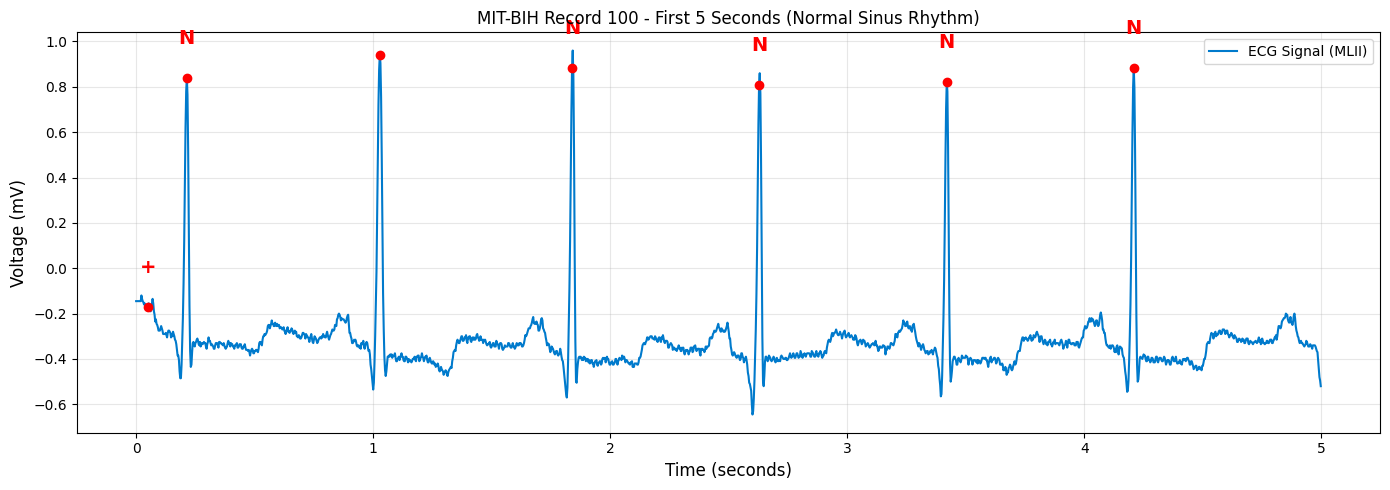

In [5]:
fs = record.fs
samples_to_plot = fs * 5

# Extract Channel 0 (usually MLII)
signal_1d = record.p_signal[:samples_to_plot, 0]
time_axis = np.arange(samples_to_plot) / fs

# Find annotations that fall within our 5-second window
mask = annotation.sample < samples_to_plot
ann_indices = annotation.sample[mask]
ann_symbols = np.array(annotation.symbol)[mask]

plt.figure(figsize=(14, 5))
plt.plot(time_axis, signal_1d, label='ECG Signal (MLII)', color='#007acc', linewidth=1.5)

# Plot the annotation markers
for idx, symbol in zip(ann_indices, ann_symbols):
    plt.plot(idx / fs, signal_1d[idx], 'ro') # Red dot on the R-peak
    plt.annotate(symbol, (idx / fs, signal_1d[idx] + 0.15),
                 fontsize=14, color='red', weight='bold', ha='center')

plt.title("MIT-BIH Record 100 - First 5 Seconds (Normal Sinus Rhythm)")
plt.xlabel("Time (seconds)", fontsize=12)
plt.ylabel("Voltage (mV)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4. Exploring an Abnormal Record
Record 119 contains Premature Ventricular Contractions (PVCs), labeled as 'V'.

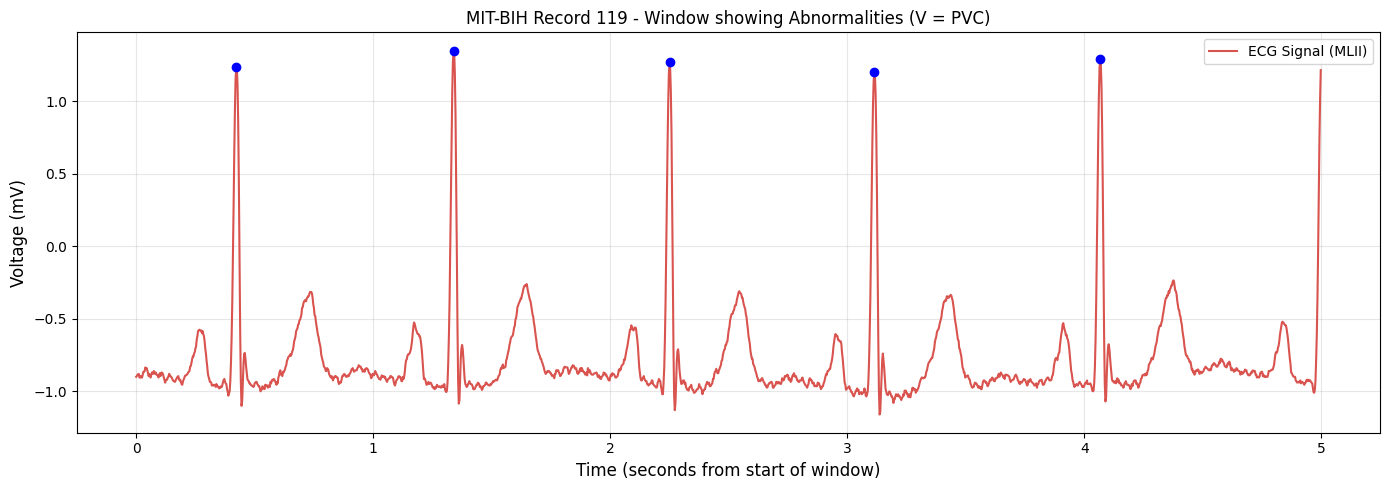

In [6]:
record_abn = wfdb.rdrecord(os.path.join(data_dir, '119'))
ann_abn = wfdb.rdann(os.path.join(data_dir, '119'), 'atr')

# Let's plot from 15 seconds to 20 seconds to catch an anomaly
start_sample = fs * 15
end_sample = fs * 20
samples_len = end_sample - start_sample

signal_abn = record_abn.p_signal[start_sample:end_sample, 0]
time_axis_abn = np.arange(samples_len) / fs

mask_abn = (ann_abn.sample >= start_sample) & (ann_abn.sample < end_sample)
ann_indices_abn = ann_abn.sample[mask_abn] - start_sample
ann_symbols_abn = np.array(ann_abn.symbol)[mask_abn]

plt.figure(figsize=(14, 5))
plt.plot(time_axis_abn, signal_abn, label='ECG Signal (MLII)', color='#d9534f', linewidth=1.5)

for idx, symbol in zip(ann_indices_abn, ann_symbols_abn):
    # Highlight 'V' (abnormal) beats differently from normal ones
    color = 'blue' if symbol != 'V' else 'black'
    font_size = 14 if symbol != 'V' else 18
    plt.plot(idx / fs, signal_abn[idx], marker='o', color=color)
    plt.annotate(symbol, (idx / fs, signal_abn[idx] + 0.3),
                 fontsize=font_size, color=color, weight='bold', ha='center')

plt.title("MIT-BIH Record 119 - Window showing Abnormalities (V = PVC)")
plt.xlabel("Time (seconds from start of window)", fontsize=12)
plt.ylabel("Voltage (mV)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Next Steps
Now that we understand the signal and annotations, our next script will handle:
1. Automated Heartbeat Extraction (windowing).
2. Patient-aware train/test splitting (DS1 vs DS2).
3. Label mapping (Normal vs Abnormal).